In [1]:
import matplotlib.pyplot as plt

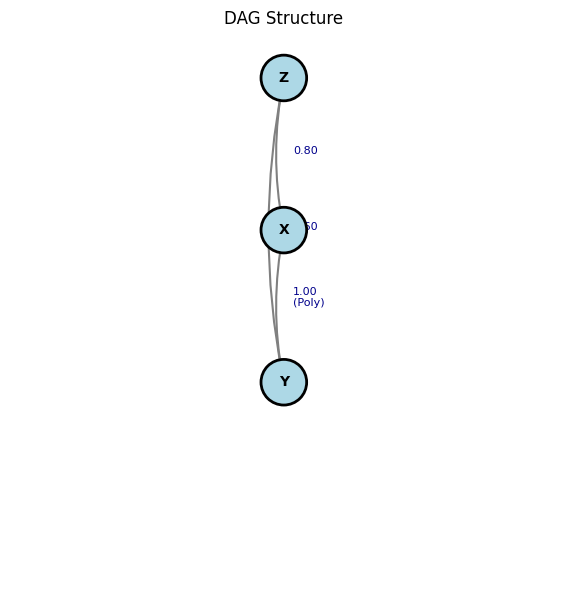

dict_keys(['Z', 'X', 'Y'])

Structural Equations:
Z = ε ~ Gaussian(μ=0.0, σ=1.0)
X = 0.80 * Z + ε ~ Gaussian(μ=0.0, σ=0.5)
Y = 0.60 * Z + X^2 + ε ~ Gaussian(μ=0.0, σ=0.5)


In [2]:
from datagenerator import DAG, DataGenerator

# Create a DAG with confounding
dag = DAG()
dag.add_node("Z", noise_std=1.0)  # Confounder
dag.add_node("X", noise_std=0.5)
dag.add_node("Y", noise_std=0.5)
dag.add_edge("Z", "X", weight=0.8)
dag.add_edge("Z", "Y", weight=0.6)
dag.add_edge("X", "Y", weight=1.0, transform="quadratic")

# Generate data
generator = DataGenerator(dag, seed=42)
data = generator.sample(n=1000)

# Or as a dictionary
data_dict = generator.sample(n=1000, return_dict=True)

dag.plot()
plt.show()

print(data_dict.keys())

print()
print(generator.show_equations())


In [3]:
from datagenerator import ClassificationDataGenerator, FeatureSpec

# Generative mode: control class balance directly
gen = ClassificationDataGenerator(
    mode="generative",
    class_balance=0.1,  # 10% positive class
    feature_specs=[
        FeatureSpec("f0", loc_by_class=(0.0, 2.0), noise_std=1.0),
        FeatureSpec("f1", loc_by_class=(-0.5, 1.0), noise_std=1.0),
        FeatureSpec("f2", parents=["f0", "f1"], parent_weights=[1.0, 0.5],
                    output_transform="tanh", noise_std=0.5),
    ],
    n_noise_features=3,
    seed=42
)
X, y = gen.generate_batch(1000)

# Or generate randomly configured data
gen_class = ClassificationDataGenerator.from_random(
    n_features=10,
    n_informative=6,
    n_direct_to_y=3,
    connectivity=0.4,
    class_balance=0.2,
    mode="causal",
    seed=42
)
X, y = gen_class.generate_batch(1000)

print(X.shape, y.shape)



(1000, 10) (1000,)


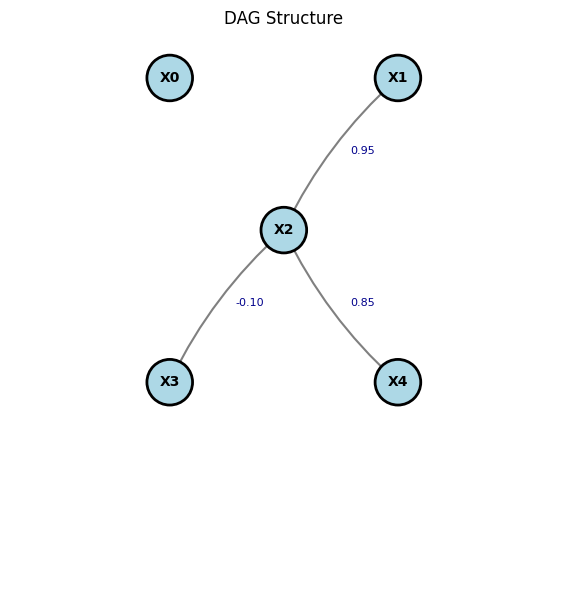

In [4]:
from datagenerator import (
    create_chain,
    create_fork,
    create_collider,
    create_mediator,
    create_instrument,
    create_random_dag,
)

# Chain: X0 -> X1 -> X2
chain = create_chain(n_nodes=3)

# Fork (confounder): Z -> X, Z -> Y
fork = create_fork(n_children=2)

# Collider: X -> Y, Z -> Y
collider = create_collider(n_parents=2)

# Mediation: X -> M -> Y and X -> Y
mediator = create_mediator(direct_effect=0.5, indirect_effect_xm=1.0, indirect_effect_my=0.8)

# Instrumental variable: Z -> X -> Y with U -> X and U -> Y
iv = create_instrument(x_y_weight=2.0)

# Random DAG
random_dag = create_random_dag(n_nodes=5, edge_probability=0.4, seed=42)

random_dag.plot()
plt.show()

In [5]:
from datagenerator import DAG, DataGenerator

dag = DAG()
dag.add_node("X", noise_std=1.0)
dag.add_node("Y", noise_std=0.5)
dag.add_edge("X", "Y", weight=1.0)

generator = DataGenerator(dag, seed=42)

# Sample with intervention do(X=2)
interventional_data = generator.sample_interventional(
    n=1000,
    interventions={"X": 2.0},
    return_dict=True
)

print(interventional_data.keys())

# Also possible with classification data in causal mode
# be carefull when interpreting the results 
interventional_data = gen_class.sample_interventional(
    n=1000,
    interventions={"f1": 2.0},
    return_dataframe=True
)

print(interventional_data.head())

dict_keys(['X', 'Y'])
         f0   f1        f4        f2        f3        f5   noise_0   noise_1  \
0 -0.000000  2.0  0.336765 -0.815807 -1.149175 -2.166143 -0.937847  1.008536   
1  2.326057  2.0 -3.574985 -0.758798  2.713362 -0.622307  1.806307 -0.326537   
2 -0.000000  2.0 -0.083995 -1.421340 -0.878827 -2.785668 -1.633385  0.438881   
3 -0.000000  2.0 -0.956372  1.407368 -2.994171  1.518296  2.155041 -0.661632   
4  1.233487  2.0 -1.233467  1.140870  0.571787  1.764061  0.307722  1.182728   

    noise_2   noise_3  y  
0  0.341172 -1.408116  0  
1 -0.769990 -0.249886  1  
2  2.683581  0.206968  0  
3  2.459262 -0.056754  0  
4 -0.117433  0.650530  0  


/tmp/ipykernel_1316/19187305.py:21: UserWarning: Interventional sampling uses the intercept calibrated for the observational distribution. The resulting class balance will differ from the target class_balance — this is expected and reflects the causal effect of the intervention.
  interventional_data = gen_class.sample_interventional(


In [6]:
from datagenerator import DAG, PolynomialTransform, CompositeTransform, SigmoidTransform

dag = DAG()
dag.add_node("X")
dag.add_node("Y")

# Using string name
dag.add_edge("X", "Y", weight=1.0, transform="quadratic")

# Using transform instance
dag.add_edge("X", "Y", weight=1.0, transform=PolynomialTransform(degrees=[1, 2, 3]))

# Composing transforms
dag.add_edge("X", "Y", weight=1.0, transform=CompositeTransform([
    PolynomialTransform(degrees=[2]),
    SigmoidTransform(scale=0.5)
]))

print(dag.show_equations())

Structural Equations:
X = ε ~ Gaussian(μ=0.0, σ=1.0)
Y = X^2 + (X + X^2 + X^3) + sigmoid(0.50 * X^2) + ε ~ Gaussian(μ=0.0, σ=1.0)


In [7]:
from datagenerator import DAG, GaussianNoise, LaplacianNoise, StudentTNoise, MixtureNoise

dag = DAG()

# Using convenience parameters
dag.add_node("X", noise_std=1.0)  # Gaussian
dag.add_node("Y", noise_type="laplacian", noise_std=0.5)
dag.add_node("Z", noise_type="student_t", noise_std=1.0, noise_params={"df": 3})

# Using noise generator instances
dag.add_node("W", noise=MixtureNoise(
    components=[GaussianNoise(std=1.0), LaplacianNoise(scale=2.0)],
    weights=[0.7, 0.3]
))

print(dag.show_equations())

Structural Equations:
X = ε ~ Gaussian(μ=0.0, σ=1.0)
Y = ε ~ Laplace(μ=0.0, b=0.5)
Z = ε ~ StudentT(df=3, σ=1.0)
W = ε ~ Mixture(Gaussian(μ=0.0, σ=1.0), Laplace(μ=0.0, b=2.0))


DAG:
  f0 --(-0.95)--> f1
  f0 --(-0.98)--> f4
  f1 --(-1.05)--> f2
  f0 --(1.47)--> f3
  f1 --(-0.97) [SigmoidTransform]--> f3
  f1 --(0.79) [ReLUTransform]--> f5
  f2 --(1.29)--> f5
DAG Structure:

X (root)
  noise: GaussianNoise(mean=0.0, std=1.0)

Y (root)
  noise: LaplacianNoise(loc=0.0, scale=0.5)

Z (root)
  noise: StudentTNoise(df=3, scale=1.0)

W (root)
  noise: MixtureNoise(components=[GaussianNoise(mean=0.0, std=1.0), LaplacianNoise(loc=0.0, scale=2.0)], weights=[0.7, 0.3])
Structural Equations:
f0 = ε ~ Gaussian(μ=0.0, σ=1.1973680290593638)
f1 = -0.95 * f0 + ε ~ Gaussian(μ=0.0, σ=1.1438651200806644)
f4 = -0.98 * f0 + ε ~ Gaussian(μ=0.0, σ=0.8123666413820411)
f2 = -1.05 * f1 + ε ~ Gaussian(μ=0.0, σ=1.131664399122065)
f3 = 1.47 * f0 + -0.97 * sigmoid(f1) + ε ~ Gaussian(μ=0.0, σ=1.46750973243421)
f5 = 0.79 * max(0, f1) + 1.29 * f2 + ε ~ Gaussian(μ=0.0, σ=1.0687411959528936)
Structural Equations:
X = ε ~ Gaussian(μ=0.0, σ=1.0)
Y = X + ε ~ Gaussian(μ=0.0, σ=0.5)


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Classification DAG - Causal (X → Y)'}>)

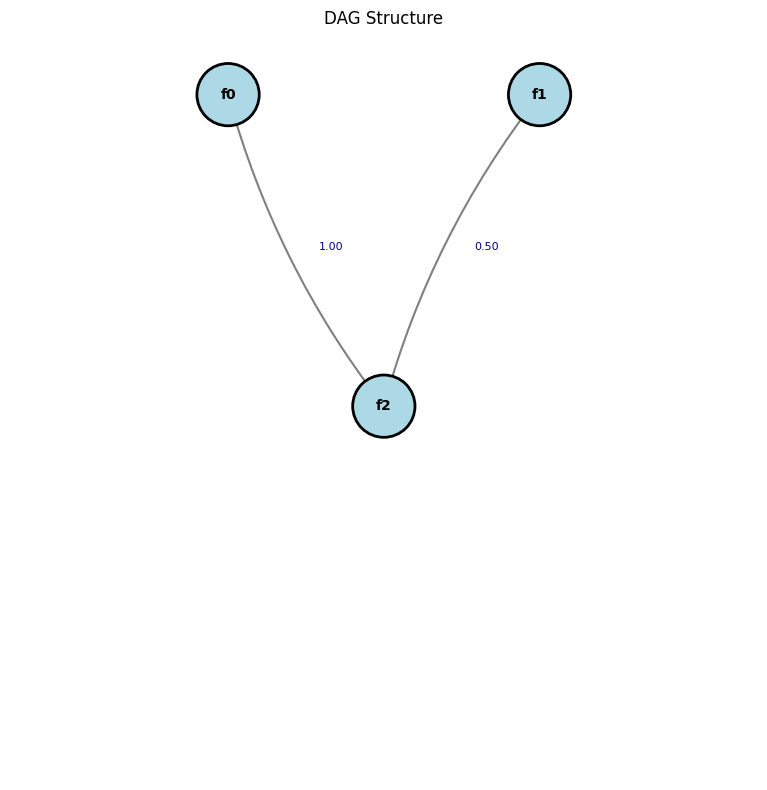

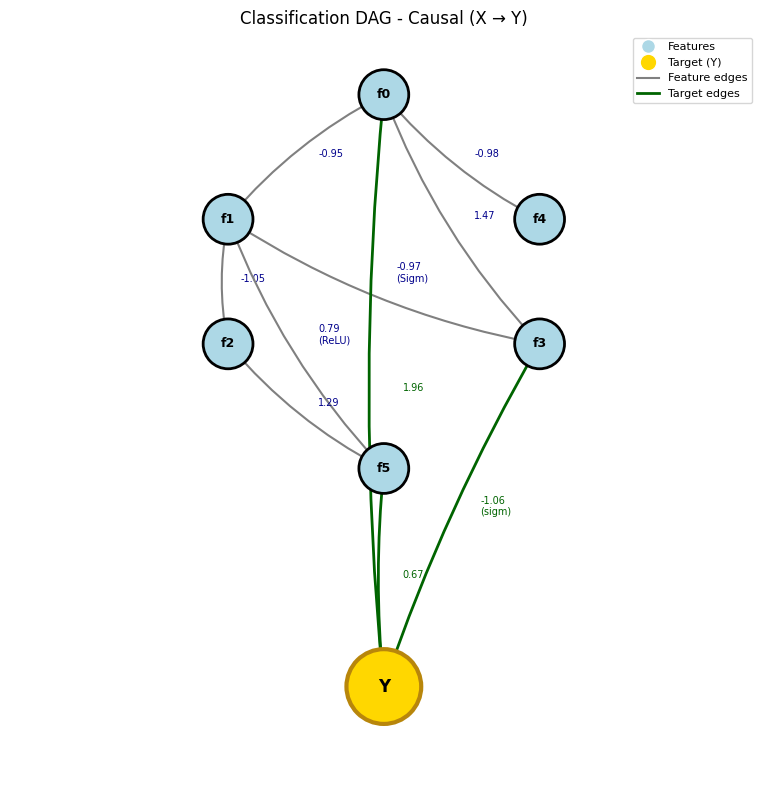

In [11]:
# Requires matplotlib
gen.dag.plot(figsize=(10, 8), show_weights=True)

# ASCII representation
print(gen_class.dag.to_ascii())

# Detailed description
print(dag.describe())

# display structural equations (both for DataGenerator and ClassificationDataGenerator)
print(gen_class.show_equations())
print(generator.show_equations())

# For ClassificationDataGenerator
gen_class.plot_dag()